## Point Cloud Generation with DriftXpress


In [91]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path
import torch
import torch.nn as nn
import torch.optim as optim
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


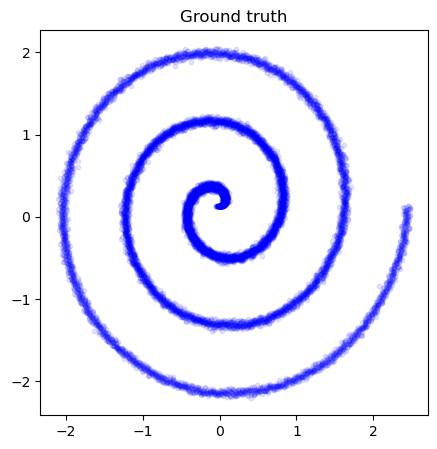

In [92]:
# 1. Spin around 3 times (3 * 2*pi)
theta = np.linspace(0, 3 * 2 * np.pi, 10000)

# Add your noise
noise = np.random.normal(0, 0.1, 10000)

# 2. Radius grows as theta grows. 
# Multiplying by 0.5 controls how tightly coiled the spiral is.
r = (0.5 * theta) + noise 

spiral_x = np.cos(theta) * r
spiral_y = np.sin(theta) * r

ground_truth = np.column_stack([spiral_x, spiral_y])

# CRITICAL FOR YOUR DRIFTING MODEL: 
# Because the spiral gets quite wide at the ends, always normalize it 
# so your neural network doesn't explode when calculating distances!
ground_truth = (ground_truth - np.mean(ground_truth, axis=0)) / np.std(ground_truth, axis=0)


plt.figure(figsize=(5, 5)) 
plt.title("Ground truth")
plt.scatter(ground_truth[:, 0], ground_truth[:, 1], s=10, alpha=0.1, color='blue')
plt.show()

ground_truth = torch.from_numpy(ground_truth).to(torch.float32).to(device)

In [93]:
# define the model architecture for f 
class neuralNet(nn.Module):
    def __init__(self):
        # Call the constructor of the parent class (nn.Module)
        super(neuralNet, self).__init__()

        self.input = nn.Linear(32, 258)
        self.initialRelu = nn.SiLU()
        self.layer1 = nn.Linear(258, 258)
        self.relu1 = nn.SiLU()
        self.layer2 = nn.Linear(258, 258)
        self.relu2 = nn.SiLU()
        self.layer3 = nn.Linear(258, 258)
        self.relu3 = nn.SiLU()
        self.output = nn.Linear(258, 2)

    def forward(self, v):
        " v is vector dim 2 (x, y)"
        v = self.input(v)
        v = self.initialRelu(v)
        v = self.layer1(v)
        v = self.relu1(v)
        v = self.layer2(v)
        v = self.relu2(v)
        v = self.layer3(v)
        v = self.relu3(v)
        v = self.output(v)
        return v

In [94]:

def select_landmarks(y_pos, num_landmarks=128):
    num_landmarks = min(num_landmarks, y_pos.shape[0])
    indices = torch.randperm(y_pos.shape[0], device=y_pos.device)[:num_landmarks]
    return y_pos[indices]

def kzu(z, landmarks, T):
    return torch.exp(-torch.cdist(z, landmarks) / T)

def build_nystrom_cache(landmarks, T, jitter=1e-5):
    K_uu = kzu(landmarks, landmarks, T)
    K_uu = K_uu + jitter * torch.eye(len(landmarks), device=landmarks.device)
    eigenvalues, eigenvectors = torch.linalg.eigh(K_uu)
    eigenvalues = torch.clamp(eigenvalues, min=jitter)
    return eigenvectors @ torch.diag(torch.rsqrt(eigenvalues)) @ eigenvectors.T

def nystrom_map(z, landmarks, K_uu_inv_sqrt, T):
    # The factor is cached: no eigendecomposition occurs during training.
    return (kzu(z, landmarks, T) @ K_uu_inv_sqrt).T

def pre_compute_summaries(y_pos, landmarks, K_uu_inv_sqrt, T):
    phi_y = nystrom_map(y_pos, landmarks, K_uu_inv_sqrt, T)
    return phi_y @ y_pos, phi_y.sum(dim=1, keepdim=True)

def attraction(y_neg, landmarks, K_uu_inv_sqrt, Ap, bp, T):
    phi = nystrom_map(y_neg, landmarks, K_uu_inv_sqrt, T)
    numerator = (Ap.T @ phi).T
    denominator = phi.T @ bp + 1e-8
    return numerator / denominator


def repulsion(y_neg, T):
    N = y_neg.shape[0]
    dist_neg = torch.cdist(y_neg, y_neg)
    
    # Remove self-interaction (Line 14)
    dist_neg += torch.eye(N, device=dist_neg.device) * 1e6 
    
    K = torch.exp(-dist_neg / T)
    
    # Line 15 normalization
    denominator = K.sum(dim=1, keepdim=True) + 1e-8
    drift_neg = (K @ y_neg) / denominator
    
    return drift_neg

def compute_V(y_neg, landmarks, K_uu_inv_sqrt, Ap, bp, T=1.0):
    V_pos = attraction(y_neg, landmarks, K_uu_inv_sqrt, Ap, bp, T)
    V_neg = repulsion(y_neg, T)
    V = V_pos - V_neg
    return V

def loss_function(generated, landmarks, K_uu_inv_sqrt, Ap, bp, T):
    with torch.no_grad():
        # y_neg is your generated batch
        V = compute_V(generated, landmarks, K_uu_inv_sqrt, Ap, bp, T)
        # Eq. (5) in the paper: regress to one full stop-gradient drift step.
        frozen_targets = (generated + V).detach()
    return mse(generated, frozen_targets)

In [109]:
# Each call is a fresh experiment; this makes comparisons reproducible.
mse = nn.MSELoss()

def training_loop(num_epochs, batch_size=1000, T=0.20, num_landmarks=512, lr=1e-3):
    model = neuralNet().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    train_losses, q_evolution = [], []
    special_iterations = [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000]
    special_iterations = [epoch for epoch in special_iterations if epoch <= num_epochs]
    gaussian = torch.randn(10000, 32, device=device)
    eval_noise = torch.randn(batch_size, 32, device=device)

    landmarks = select_landmarks(ground_truth, num_landmarks)
    K_uu_inv_sqrt = build_nystrom_cache(landmarks, T)
    Ap, bp = pre_compute_summaries(ground_truth, landmarks, K_uu_inv_sqrt, T)

    print('Training started')
    for epoch in range(num_epochs + 1):
        model.train()
        optimizer.zero_grad()
        noise_indices = torch.randperm(len(gaussian), device=device)[:batch_size]
        generated = model(gaussian[noise_indices])
        loss = loss_function(generated, landmarks, K_uu_inv_sqrt, Ap, bp, T)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

        if epoch in special_iterations or epoch % 100 == 0:
            model.eval()
            with torch.no_grad():
                evaluation = model(eval_noise)
            if epoch in special_iterations:
                q_evolution.append(evaluation.cpu().numpy())
            if epoch % 100 == 0:
                print(f'Epoch [{epoch}/{num_epochs}], loss: {loss.item():.6f}')

    print('Finished')
    return model, train_losses, q_evolution
    

In [123]:
f_trained, losses, evolution = training_loop(5000, T=0.018, num_landmarks=500)

Training started
Epoch [0/5000], loss: 0.010891
Epoch [100/5000], loss: 0.000129
Epoch [200/5000], loss: 0.000856
Epoch [300/5000], loss: 0.000159
Epoch [400/5000], loss: 0.002211
Epoch [500/5000], loss: 0.003022
Epoch [600/5000], loss: 0.000905
Epoch [700/5000], loss: 0.000200
Epoch [800/5000], loss: 0.005052
Epoch [900/5000], loss: 0.002718
Epoch [1000/5000], loss: 0.000388
Epoch [1100/5000], loss: 0.003027
Epoch [1200/5000], loss: 0.007165
Epoch [1300/5000], loss: 0.001402
Epoch [1400/5000], loss: 0.002384
Epoch [1500/5000], loss: 0.006644
Epoch [1600/5000], loss: 0.004224
Epoch [1700/5000], loss: 0.001537
Epoch [1800/5000], loss: 0.003684
Epoch [1900/5000], loss: 0.004981
Epoch [2000/5000], loss: 0.010077
Epoch [2100/5000], loss: 0.005347
Epoch [2200/5000], loss: 0.003728
Epoch [2300/5000], loss: 0.003882
Epoch [2400/5000], loss: 0.004448
Epoch [2500/5000], loss: 0.003799
Epoch [2600/5000], loss: 0.001352
Epoch [2700/5000], loss: 0.007718
Epoch [2800/5000], loss: 0.006140
Epoch [29

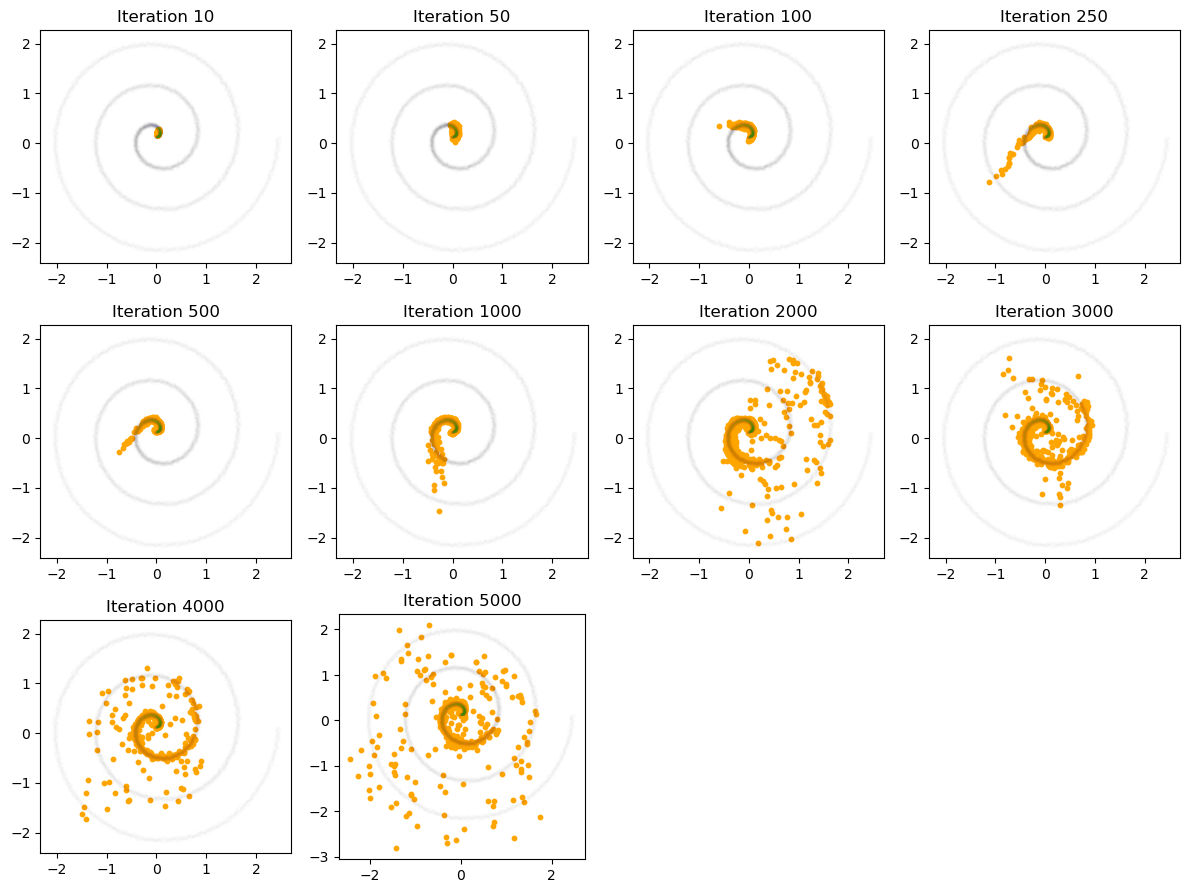

In [124]:
# Every panel uses the same latent evaluation batch; lower SWD is better.
its = [10, 50, 100, 250, 500, 1000, 2000, 3000, 4000, 5000]

ncols = 4
nrows = int(np.ceil(len(its) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))

# Flatten the 2D axes array to 1D to make iteration simple
axes = np.atleast_1d(axes).flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].scatter(ground_truth[:, 0].cpu(), ground_truth[:, 1].cpu(), s=2, alpha=0.005, color='steelblue')
    axes[i].set_title(f"Iteration {its[i]}")
    axes[i].set_aspect('equal')

for ax in axes[len(its):]:
    ax.set_visible(False)

plt.tight_layout()

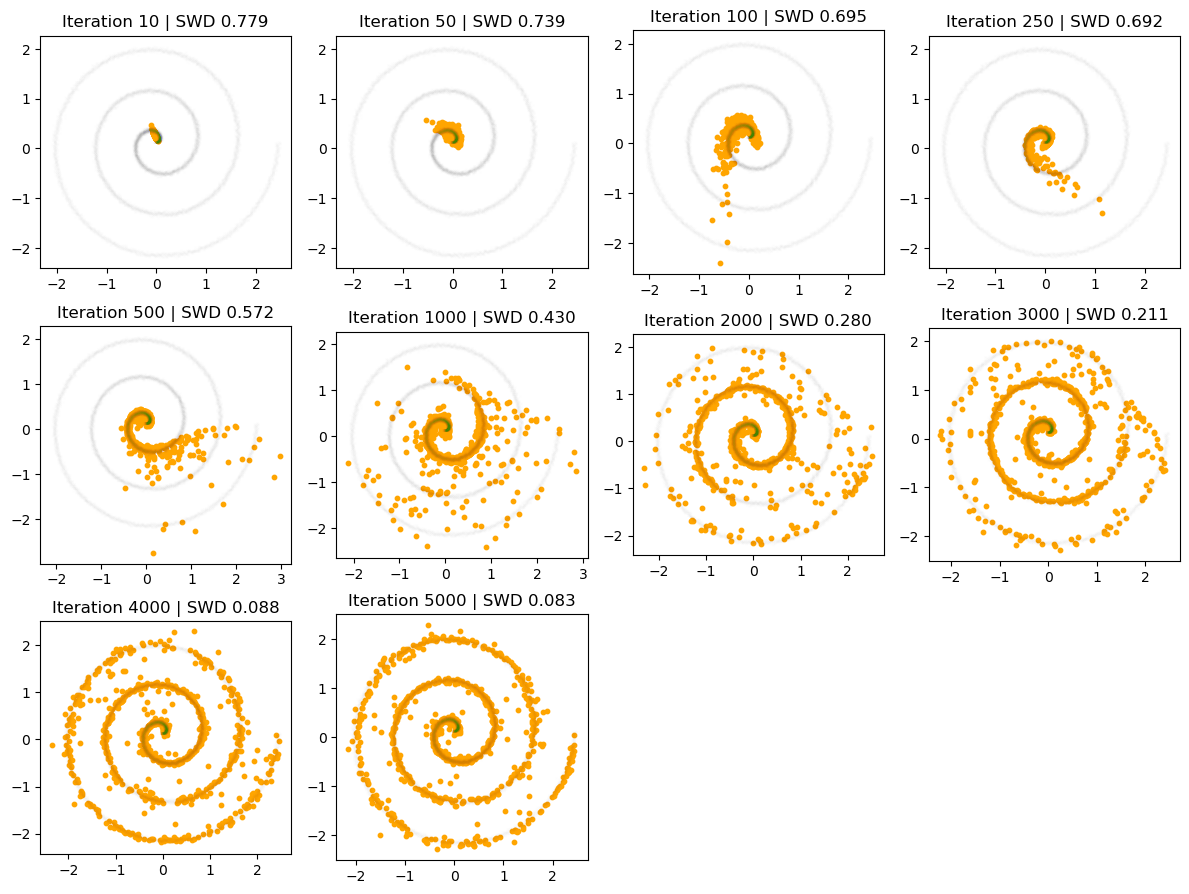

In [90]:
# Every panel uses the same latent evaluation batch; lower SWD is better.
its = [10, 50, 100, 250, 500, 1000, 2000]

ncols = 4
nrows = int(np.ceil(len(its) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))

# Flatten the 2D axes array to 1D to make iteration simple
axes = np.atleast_1d(axes).flatten() 

for i in range(len(its)):
    x = evolution[i][:, 0]
    y = evolution[i][:, 1]
    
    axes[i].scatter(x, y, s=10, alpha=1, color='orange')
    axes[i].scatter(ground_truth[:, 0].cpu(), ground_truth[:, 1].cpu(), s=2, alpha=0.005, color='steelblue')
    axes[i].set_title(f"Iteration {its[i]}")
    axes[i].set_aspect('equal')

for ax in axes[len(its):]:
    ax.set_visible(False)

plt.tight_layout()